1.1 ¿Qué es Seaborn y por qué usarlo en vez de Matplotlib puro?
Seaborn es una librería de visualización estadística construida sobre Matplotlib y pensada para trabajar directamente con DataFrames de Pandas. Proporciona gráficos de alto nivel, estilos agradables por defecto y funciones que comprenden la semántica de los datos en Python.

¿Qué es?
Una capa superior sobre Matplotlib que facilita crear gráficos informativos y elegantes con menos código. Incluye gráficos estadísticos comunes (distribuciones, relaciones, categóricos, regresión, mapas de calor) y atajos para trabajar con grillas (facetas) y aplicar estilos coherentes.

Ventajas sobre Matplotlib puro
API de alto nivel: funciones como displot, catplot, relplot, heatmap y pairplot resuelven de una vez tareas que en Matplotlib requieren muchos pasos.
Semántica declarativa: parámetros como hue, style, size, col y row conectan columnas del DataFrame con la estética visual sin código extra.
Estilos y paletas predefinidos: mejoran la legibilidad y evitan invertir tiempo en configuración manual.
Integración natural con Pandas: pasás el DataFrame y los nombres de las columnas sin separar manualmente series x e y.
Objetos modernos (Seaborn Objects ≥ 0.13): una gramática coherente para combinar capas y construir composiciones avanzadas, similar a ggplot.
Matplotlib sigue siendo la base y ofrece control fino; Seaborn acelera la mayoría de los casos manteniendo la posibilidad de personalizar con Matplotlib cuando haga falta.
1.2 Instalación y configuración inicial
Instalación (Windows/macOS)
Actualizá a la versión más reciente mediante pip:

pip install --upgrade seaborn
Verificar versión e importar

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

print(sns.__version__)

0.13.2


Activar un tema por defecto
Desde la versión 0.12, la forma recomendada es set_theme:

In [3]:
sns.set_theme()                     # Tema estandar agradable y legible
# Opcional: elegir estilo y contexto desde el inicio
sns.set_theme(style="whitegrid", context="notebook")

Cargar un dataset de ejemplo y crear tu primer gráfico

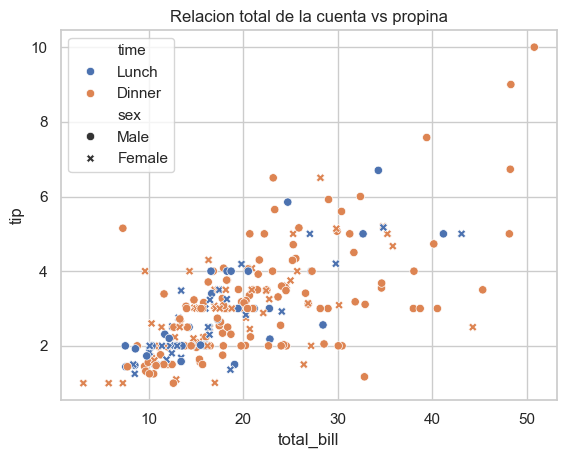

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")     # DataFrame con datos de propinas
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time", style="sex")
plt.title("Relacion total de la cuenta vs propina")
plt.show()

Las tres primeras filas del dataset tips:


total_bill	tip	sex	smoker	day	time	size
16.99	1.01	Female	No	Sun	Dinner	2
10.34	1.66	Male	No	Sun	Dinner	3
21.01	3.50	Male	No	Sun	Dinner	3

API de figura a nivel alto: grillas y facetas
Las funciones de nivel figura (displot, catplot, relplot, lmplot) crean figuras completas y facetas automáticamente:

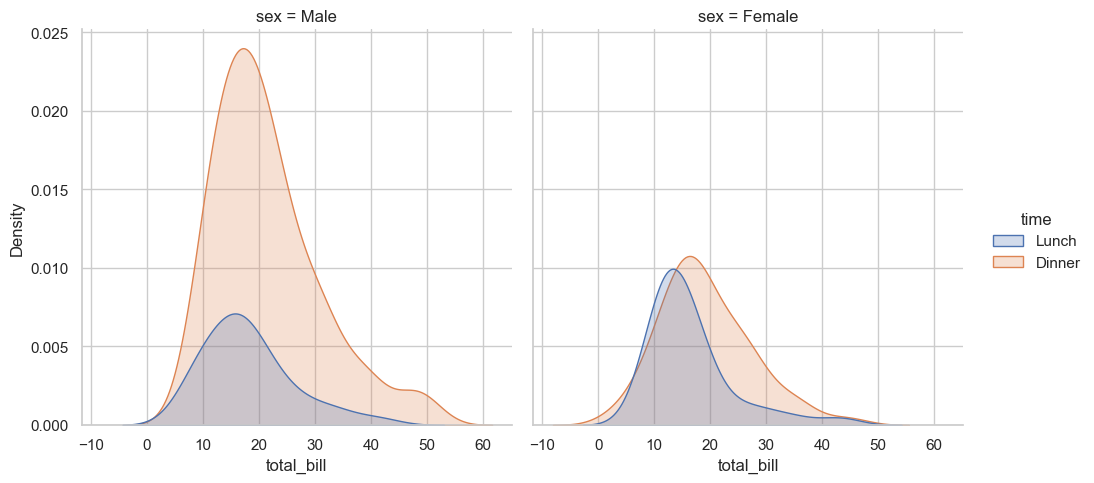

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

sns.displot(data=tips, x="total_bill", hue="time", kind="kde", fill=True, col="sex")
plt.show()

(Opcional) Seaborn Objects (≥ 0.13)
Una gramática unificada para construir gráficos por capas:

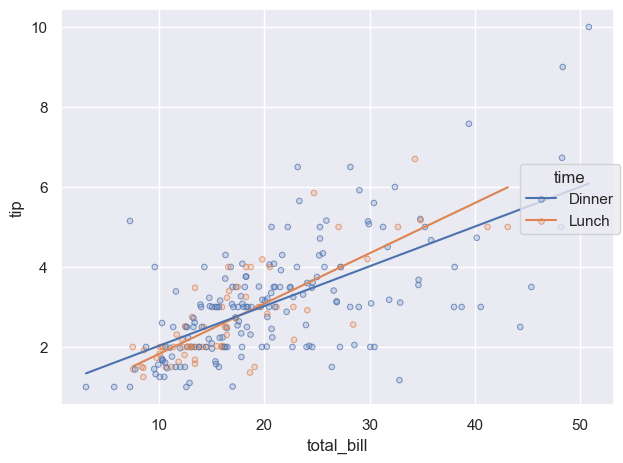

In [6]:
import seaborn as sns
import seaborn.objects as so

tips = sns.load_dataset("tips")

(
    so.Plot(tips, x="total_bill", y="tip", color="time")
      .add(so.Dots(alpha=0.7))
      .add(so.Line(), so.PolyFit(order=1))  # Recta de regresion
      .theme(sns.plotting_context("notebook"))
).show()

1.3 Estilos y paletas de colores predefinidas
Estilos
Seaborn incluye estilos coherentes para fondos, rejillas y ticks:

darkgrid (por defecto tradicional)
whitegrid (ideal para datos categóricos)
dark
white
ticks
Aplicación:

In [7]:
sns.set_theme(style="whitegrid")  # "darkgrid", "white", "dark" o "ticks"

Contextos
Ajustan el tamaño de etiquetas, títulos y ticks según el uso:

paper
notebook (default)
talk
poster

In [8]:
sns.set_theme(context="talk")  # Ideal para presentaciones

Paletas de color
Elegí según el tipo de dato:

Cualitativas: "deep", "muted", "bright", "pastel", "dark", "colorblind".
Secuenciales: "rocket", "mako", "flare", "crest", "viridis", "magma", entre otras.
Divergentes: "vlag", "icefire", "coolwarm", "Spectral".
Aplicación global o local:

<Axes: xlabel='total_bill', ylabel='tip'>

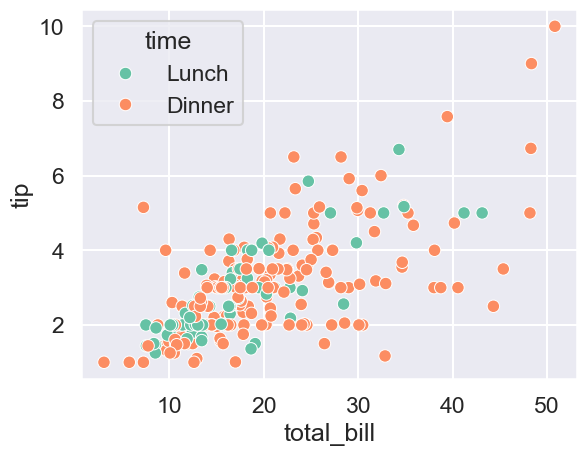

In [9]:
# Global: todos los graficos siguientes
sns.set_palette("deep")  # O cualquier nombre de paleta

# Local: solo para un grafico
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time", palette="Set2")

Paletas continuas con cubehelix y utilidades adicionales:

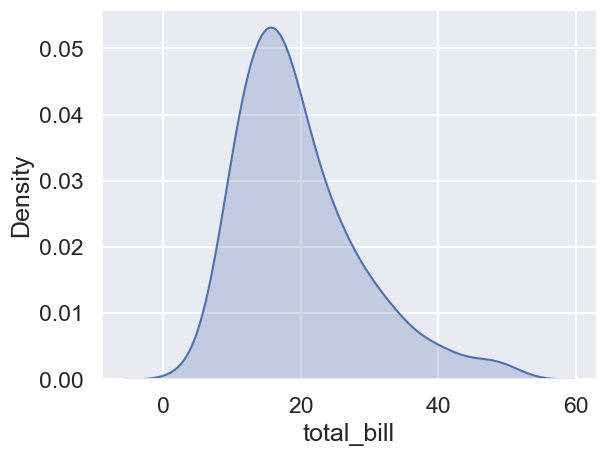

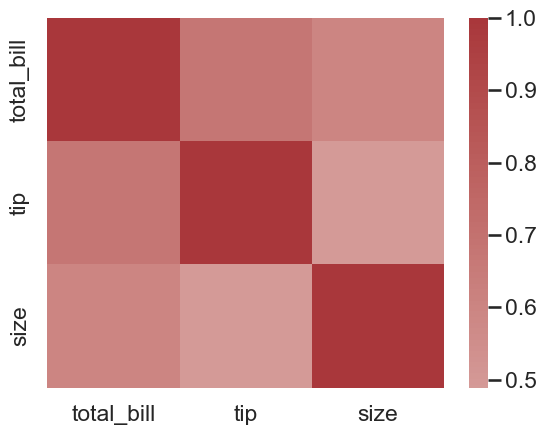

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

# Paleta continua personalizada (secuencial)
pal = sns.color_palette("mako", as_cmap=True)
sns.kdeplot(data=tips, x="total_bill", fill=True, cmap=pal)
plt.show()

# Paleta divergente para resaltar alrededor de un punto medio
sns.heatmap(tips.corr(numeric_only=True), cmap="vlag", center=0)
plt.show()

Combinar Seaborn con Matplotlib
Podés seguir usando Matplotlib para títulos y etiquetas:

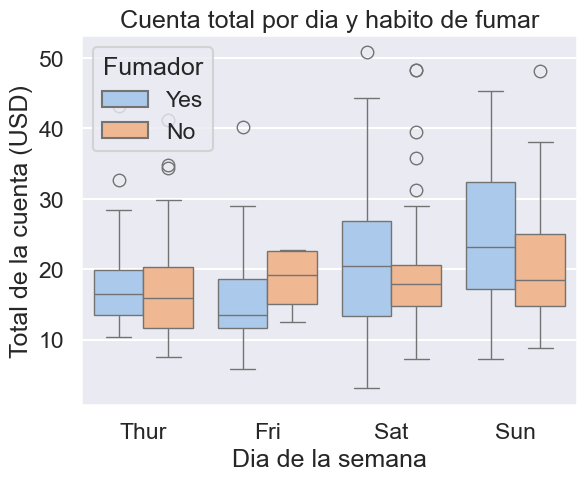

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

sns.boxplot(data=tips, x="day", y="total_bill", hue="smoker", palette="pastel")
plt.title("Cuenta total por dia y habito de fumar")
plt.xlabel("Dia de la semana")
plt.ylabel("Total de la cuenta (USD)")
plt.legend(title="Fumador")
plt.show()

1.4 Buenas prácticas rápidas

Elegí la paleta según el tipo de dato: cualitativa para categorías, secuencial o divergente para valores continuos.

Usá hue, style y size para codificar variables adicionales sin saturar el gráfico.

Utilizá facetas (row, col) cuando comparar subgrupos mejore la lectura.

Evitá abusar del color: mantené contraste suficiente y considerá paletas aptas para daltonismo.

Apoyate en Seaborn Objects para composiciones complejas y capas extra (tendencias, intervalos).


Checklist de inicio rápido

pip install seaborn

import seaborn as sns; sns.set_theme(style="whitegrid", context="notebook")

df = sns.load_dataset("tips") (u otro dataset propio)

Comenzá con displot, relplot, catplot, heatmap o pairplot

Ajustá paleta y estilo; completá con títulos y etiquetas de Matplotlib
